# SENTIMENT ANALYSIS OF FLIPKART PRODUCT REVIEWS USING NLP AND MACHINE LEARNING

### Dataset: Flipkart Product Reviews
### NLP Technique: TF-IDF
### Task: Sentiment Classification
### Sentiment Classes: Positive, Neutral, Negative

 ## 1. Importing Required Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. Loading the Dataset


In [2]:
# Load the dataset
df = pd.read_csv("Dataset-SA.csv")

# Display the first 5 rows
df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


## 3. Dataset Overview


In [3]:
# Display the number of rows and columns
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display basic information about the dataset
print("\nDataset Information:")
df.info()

Dataset Shape: (205052, 6)

Column Names:
['product_name', 'product_price', 'Rate', 'Review', 'Summary', 'Sentiment']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   product_name   205052 non-null  object
 1   product_price  205052 non-null  object
 2   Rate           205052 non-null  object
 3   Review         180388 non-null  object
 4   Summary        205041 non-null  object
 5   Sentiment      205052 non-null  object
dtypes: object(6)
memory usage: 9.4+ MB


## 4. Data Cleaning


In [4]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

Missing Values:
product_name         0
product_price        0
Rate                 0
Review           24664
Summary             11
Sentiment            0
dtype: int64

Number of Duplicate Rows:
34375


## 5. Removing Missing Reviews and Duplicate Records


In [5]:
# Remove rows with missing Review values
df = df.dropna(subset=['Review'])

# Remove duplicate rows
df = df.drop_duplicates()

# Reset the index
df = df.reset_index(drop=True)

# Check the dataset after cleaning
print("Dataset Shape After Cleaning:", df.shape)
print("\nMissing values in Review:", df['Review'].isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

Dataset Shape After Cleaning: (154475, 6)

Missing values in Review: 0
Duplicate rows: 0


## 6. Sentiment Distribution


In [6]:
# Count the number of reviews in each sentiment category
sentiment_counts = df['Sentiment'].value_counts()

print("Number of reviews in each sentiment category:")
print(sentiment_counts)

Number of reviews in each sentiment category:
Sentiment
positive    122813
negative     23353
neutral       8309
Name: count, dtype: int64


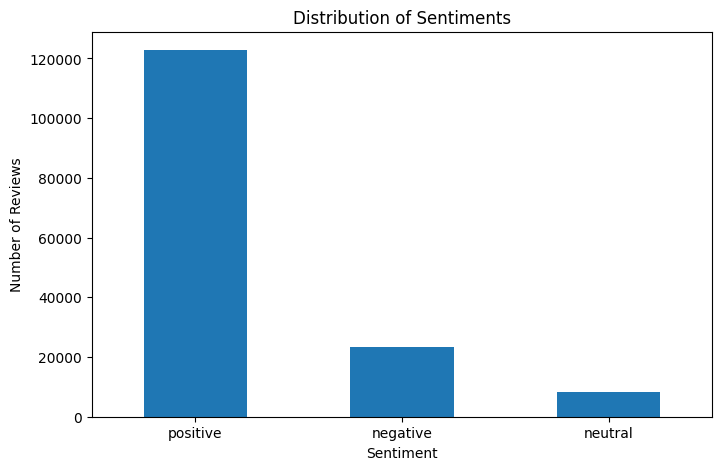

In [7]:
# Plot the sentiment distribution
plt.figure(figsize=(8, 5))

sentiment_counts.plot(kind='bar')

plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

## 7. Text Preprocessing


In [8]:
import re

# Function to clean review text
def clean_text(text):
    text = str(text).lower()                  # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text)      # Remove numbers and special characters
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

# Apply the cleaning function to the Review column
df['Cleaned_Review'] = df['Review'].apply(clean_text)

# Display original and cleaned reviews
df[['Review', 'Cleaned_Review']].head()

,Review,Cleaned_Review
0,super!,super
1,awesome,awesome
2,fair,fair
3,useless product,useless product
4,fair,fair


## 8. Feature Extraction using TF-IDF


In [9]:
# Create the TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Convert cleaned reviews into TF-IDF features
X = tfidf.fit_transform(df['Cleaned_Review'])

# Target variable
y = df['Sentiment']

print("TF-IDF Matrix Shape:", X.shape)
print("Number of Features:", len(tfidf.get_feature_names_out()))

TF-IDF Matrix Shape: (154475, 4158)
Number of Features: 4158


## 9. Train-Test Split


In [10]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 123580
Testing samples: 30895


## 10. Model Training – Logistic Regression


In [11]:
# Create the Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


## 11. Model Prediction


In [12]:
# Predict the sentiment of the test data
y_pred = lr_model.predict(X_test)

# Display the first 10 predictions
print("First 10 Predicted Sentiments:")
print(y_pred[:10])

First 10 Predicted Sentiments:
['positive' 'negative' 'positive' 'negative' 'positive' 'negative'
 'negative' 'positive' 'positive' 'positive']


## 12. Model Evaluation


In [13]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 90.26 %

Classification Report:


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

    negative       0.84      0.78      0.81      4670
     neutral       0.00      0.00      0.00      1662
    positive       0.91      0.99      0.95     24563

    accuracy                           0.90     30895
   macro avg       0.58      0.59      0.59     30895
weighted avg       0.85      0.90      0.88     30895



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 13. Confusion Matrix


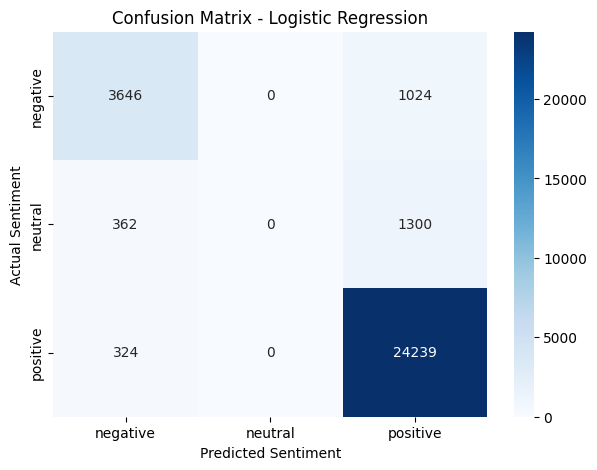

In [14]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=lr_model.classes_)

# Display the confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',              # Light blue color
    xticklabels=lr_model.classes_,
    yticklabels=lr_model.classes_
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()

## 14. Testing with New Customer Reviews

In [15]:
# Function to predict sentiment of a new review
def predict_sentiment(review):
    cleaned_review = clean_text(review)
    review_tfidf = tfidf.transform([cleaned_review])
    prediction = lr_model.predict(review_tfidf)
    return prediction[0]

# Test reviews
test_reviews = [
    "The product is amazing and I am very happy with the quality.",
    "The product is okay, nothing special.",
    "Very poor quality. I am completely disappointed with this product."
]

# Display predictions
for review in test_reviews:
    sentiment = predict_sentiment(review)
    print("Review:", review)
    print("Predicted Sentiment:", sentiment)
    print("-" * 70)

Review: The product is amazing and I am very happy with the quality.
Predicted Sentiment: positive
----------------------------------------------------------------------
Review: The product is okay, nothing special.
Predicted Sentiment: positive
----------------------------------------------------------------------
Review: Very poor quality. I am completely disappointed with this product.
Predicted Sentiment: negative
----------------------------------------------------------------------


## 15. Comparing Machine Learning Models

In [16]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# Train Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Train Linear SVM
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train, y_train)

# Predictions
nb_pred = nb_model.predict(X_test)
svm_pred = svm_model.predict(X_test)

# Compare accuracies
print("Model Performance")
print("-" * 40)

print("Logistic Regression Accuracy:",
      round(accuracy_score(y_test, y_pred) * 100, 2), "%")

print("Naive Bayes Accuracy:",
      round(accuracy_score(y_test, nb_pred) * 100, 2), "%")

print("Linear SVM Accuracy:",
      round(accuracy_score(y_test, svm_pred) * 100, 2), "%")

Model Performance
----------------------------------------
Logistic Regression Accuracy: 90.26 %
Naive Bayes Accuracy: 89.44 %
Linear SVM Accuracy: 90.27 %


## 16. Final Model Evaluation – Linear SVM

In [17]:
# Generate the classification report for Linear SVM
print("Linear SVM Classification Report:")
print(classification_report(y_test, svm_pred))

Linear SVM Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.78      0.81      4670
     neutral       0.25      0.00      0.00      1662
    positive       0.91      0.99      0.95     24563

    accuracy                           0.90     30895
   macro avg       0.67      0.59      0.59     30895
weighted avg       0.87      0.90      0.88     30895



## 17. Confusion Matrix – Linear SVM

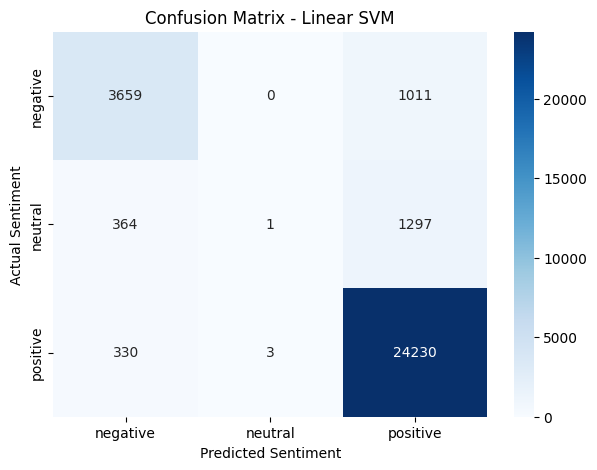

In [18]:
# Generate the confusion matrix for Linear SVM
cm_svm = confusion_matrix(y_test, svm_pred, labels=svm_model.classes_)

# Display the confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_
)

plt.title('Confusion Matrix - Linear SVM')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()

## 18. Testing New Customer Reviews – Linear SVM

In [19]:
# Function to predict sentiment using the final Linear SVM model
def predict_sentiment_svm(review):
    cleaned_review = clean_text(review)
    review_tfidf = tfidf.transform([cleaned_review])
    prediction = svm_model.predict(review_tfidf)
    return prediction[0]


# Test new customer reviews
test_reviews = [
    "The product quality is excellent and I am very happy with it.",
    "The product is okay, but nothing special.",
    "Very poor quality and completely disappointing."
]


# Display predictions
for review in test_reviews:
    sentiment = predict_sentiment_svm(review)

    print("Review:", review)
    print("Predicted Sentiment:", sentiment)
    print("-" * 70)

Review: The product quality is excellent and I am very happy with it.
Predicted Sentiment: positive
----------------------------------------------------------------------
Review: The product is okay, but nothing special.
Predicted Sentiment: positive
----------------------------------------------------------------------
Review: Very poor quality and completely disappointing.
Predicted Sentiment: negative
----------------------------------------------------------------------


## 19. Model Accuracy Comparison

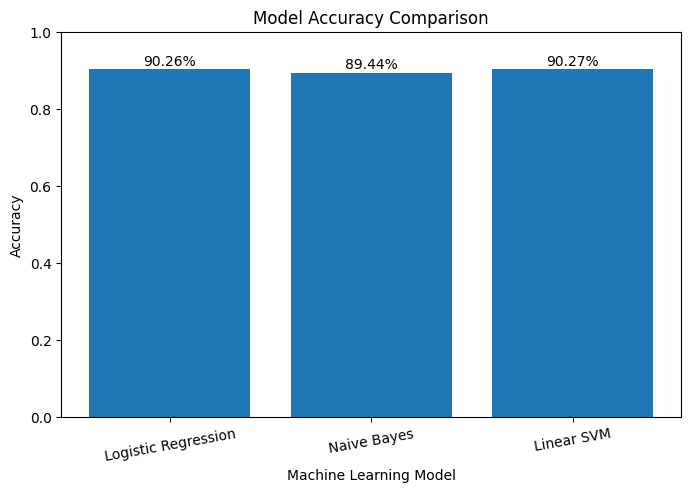

In [20]:
# Store model accuracies
models = ['Logistic Regression', 'Naive Bayes', 'Linear SVM']
accuracies = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, svm_pred)
]

# Create bar chart
plt.figure(figsize=(8, 5))

plt.bar(models, accuracies)

plt.title('Model Accuracy Comparison')
plt.xlabel('Machine Learning Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

# Display accuracy values above bars
for i, accuracy in enumerate(accuracies):
    plt.text(i, accuracy + 0.01, f'{accuracy * 100:.2f}%',
             ha='center')

plt.xticks(rotation=10)
plt.show()

## 20. Final Results

In [21]:
# Calculate final accuracy of the selected model
final_accuracy = accuracy_score(y_test, svm_pred)

print("Final Model: Linear SVM")
print("Final Accuracy:", round(final_accuracy * 100, 2), "%")

print("\nModel Comparison:")
print("Logistic Regression:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("Naive Bayes:", round(accuracy_score(y_test, nb_pred) * 100, 2), "%")
print("Linear SVM:", round(accuracy_score(y_test, svm_pred) * 100, 2), "%")

Final Model: Linear SVM
Final Accuracy: 90.27 %

Model Comparison:
Logistic Regression: 90.26 %
Naive Bayes: 89.44 %
Linear SVM: 90.27 %


## 21. Conclusion

The project successfully developed an NLP-based sentiment analysis system for Flipkart product reviews. The review text was cleaned and converted into numerical features using TF-IDF. Three machine learning models were trained and compared: Logistic Regression, Naive Bayes, and Linear SVM.

Among the three models, Linear SVM achieved the highest accuracy of 90.27% and was selected as the final model for sentiment classification. The system can classify new product reviews into Positive, Neutral, or Negative sentiment categories.

This project demonstrates how Natural Language Processing and machine learning can be used to automatically analyze customer opinions from product reviews.